# CFR Chunks Token Size Analysis
This notebook analyzes the approximate token sizes of the extracted CFR chunks stored in `backend/data/chunks/cfr_chunks.json`.

In [1]:
%pip install pandas 


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots display in the notebook
%matplotlib inline

In [ ]:
file_path = "data/chunks/cfr_chunks.json"

try:
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    chunks = data.get("chunks", [])
    print(f"Successfully loaded {len(chunks)} chunks.")
except FileNotFoundError:
    print(f"File not found: {file_path}")
    chunks = []

Successfully loaded 59105 chunks.


In [4]:
if chunks:
    # Extract token sizes into a DataFrame
    token_counts = [chunk.get("token_count_approx", 0) for chunk in chunks]
    df = pd.DataFrame({"token_count": token_counts})
    
    # Display summary statistics
    print("--- Summary Statistics ---")
    display(df.describe())

--- Summary Statistics ---


,token_count
count,59105.000000
mean,55.522240
std,72.150606
min,2.000000
25%,20.000000
50%,37.000000
75%,67.000000
max,7796.000000


/opt/homebrew/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: divide by zero encountered in dot
  c = dot(X, X_T.conj())
/opt/homebrew/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: overflow encountered in dot
  c = dot(X, X_T.conj())
/opt/homebrew/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


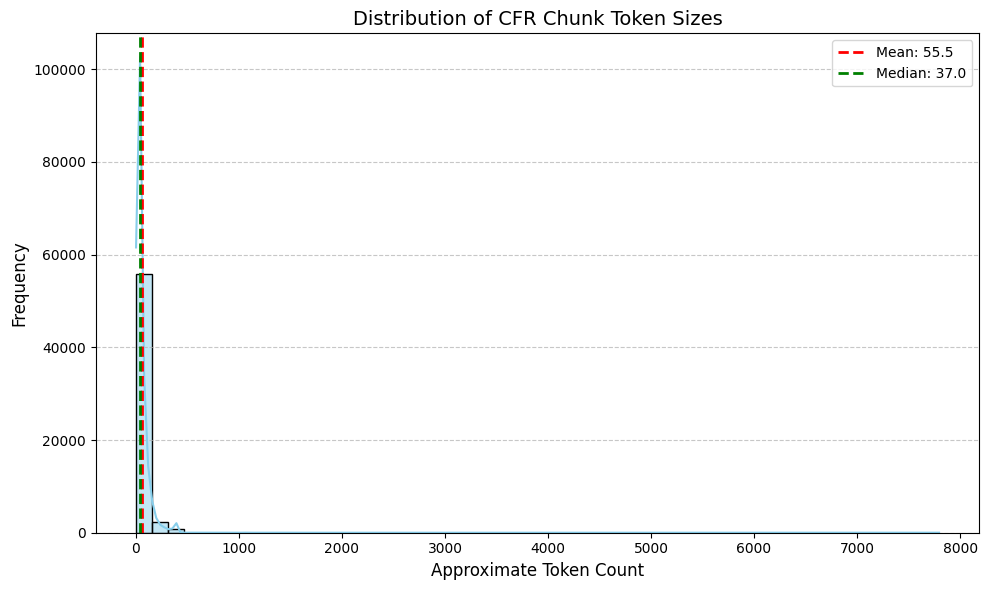

In [5]:
if chunks:
    plt.figure(figsize=(10, 6))
    sns.histplot(df["token_count"], bins=50, kde=True, color="skyblue")
    
    mean_val = df["token_count"].mean()
    median_val = df["token_count"].median()
    
    plt.axvline(mean_val, color="red", linestyle="dashed", linewidth=2, label=f"Mean: {mean_val:.1f}")
    plt.axvline(median_val, color="green", linestyle="dashed", linewidth=2, label=f"Median: {median_val:.1f}")
    
    plt.title("Distribution of CFR Chunk Token Sizes", fontsize=14)
    plt.xlabel("Approximate Token Count", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()